# Klasifikacija proteinskih sekvenci 

In [1]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## Priprema podataka

### Definisanje klasa

In [2]:
CLASSES = {
    "Hydrolase": "hydrolase.tsv",
    "Transport protein": "transport_protein.tsv",
    "Transcription factor": "transcription_factor.tsv",
    "Receptor": "receptor.tsv",
    "Structural protein": "structural_protein.tsv"
}

### Učitavanje i spajanje TSV fajlova

In [3]:
all_dfs = []
for label, filename in CLASSES.items():
    df = pd.read_csv(f"data\\{filename}", sep="\t")
    df["label"] = label
    print(f"{label}: {len(df)} proteina")
    all_dfs.append(df)

Hydrolase: 2407 proteina
Transport protein: 1242 proteina
Transcription factor: 1418 proteina
Receptor: 1605 proteina
Structural protein: 774 proteina


In [4]:
dataset = pd.concat(all_dfs, ignore_index=True)
os.makedirs("data", exist_ok=True)
dataset.to_csv(os.path.join("data", "uniprot_protein.csv"), index=False)
print(f"CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!")

CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!


## Upoznavanje sa skupom podataka

### Osnovne informacije

In [ ]:
print(f"\nUkupan broj proteina: {len(dataset)}")
print(f"Broj klasa: {dataset['label'].nunique()}")
print(f"Dimenzije dataseta: {dataset.shape}")
print(f"\nKolone: {list(dataset.columns)}")
dataset.head()


Ukupan broj proteina: 7446
Broj klasa: 5
Dimenzije dataseta: (7446, 5)


In [5]:
print(f"\nUkupno proteina: {len(dataset)}")


Ukupno proteina: 7446


In [6]:
dataset.head()

,Entry,Sequence,Protein names,Keywords,label
0,A0A1B0GTW7,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,Ciliated left-right organizer metallopeptidase...,Alternative splicing;Disease variant;Glycoprot...,Hydrolase
1,A1A4Y4,MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...,Immunity-related GTPase family M protein (EC 3...,Alternative splicing;Autophagy;Cell membrane;C...,Hydrolase
2,A1KZ92,MEPRLFCWTTLFLLAGWCLPGLPCPSRCLCFKSTVRCMHLMLDHIP...,Probable oxidoreductase PXDNL (EC 1.-.-.-) (Ca...,Alternative splicing;Calcium;Cell membrane;Cyt...,Hydrolase
3,A1Z1Q3,MYPSNKKKKVWREEKERLLKMTLEERRKEYLRDYIPLNSILSWKEE...,ADP-ribose glycohydrolase MACROD2 (MACRO domai...,3D-structure;Alternative splicing;DNA damage;H...,Hydrolase
4,A2A288,MEHPSKMEFFQKLGYDREDVLRVLGKLGEGALVNDVLQELIRTGSR...,Probable ribonuclease ZC3H12D (EC 3.1.-.-) (MC...,Alternative splicing;Chromosomal rearrangement...,Hydrolase


In [7]:
print(f"\nKolone: {list(dataset.columns)}")


Kolone: ['Entry', 'Sequence', 'Protein names', 'Keywords', 'label']


### Provjera i čišćenje sekvenci

In [8]:
# Redovi sa praznom sekvencom

print(f"Broj redova sa praznom sekvencom: {dataset['Sequence'].isna().sum()}")

Broj redova sa praznom sekvencom: 0


In [9]:
# Provjera da li je sekvenca sadrzi iskljucivo standardnih 20 aminokiselina
# Standardne aminokiseline: A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y

def valid_sequence(seq):
    valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
    seq = str(seq).upper().strip()

    unvalid = [aa for aa in seq if aa not in valid_aa]
    if unvalid:
        print(f"Nevalidni karakteri: {set(unvalid)}")
        return None
    
    if len(seq) < 50:
        print(f"Prekratka sekvenca: {len(seq)}")
        return None
    
    return seq

dataset['Sequence'] = dataset['Sequence'].apply(valid_sequence)

total_before = len(dataset)
dataset = dataset.dropna(subset=['Sequence'])
total_after = len(dataset)

print(f"Prije odbacivanja: {total_before} proteina")
print(f"Nakon odbacivanja: {total_after} proteina")

Prekratka sekvenca: 34
Nevalidni karakteri: {'U'}
Prekratka sekvenca: 25
Prije odbacivanja: 7446 proteina
Nakon odbacivanja: 7443 proteina


### Podjela skupa na ulazne i ciljne atribute

In [10]:
# Priprema x i y
x = dataset['Sequence'].values
y = dataset['label'].values

In [11]:
# Pretvaranje naziva klasa u brojeve (Label encoding)
le = LabelEncoder()
y = le.fit_transform(y)

for num, label in enumerate(le.classes_):
    print(f"{num} -> {label}")

0 -> Hydrolase
1 -> Receptor
2 -> Structural protein
3 -> Transcription factor
4 -> Transport protein


### Provjera balansiranosti klasa

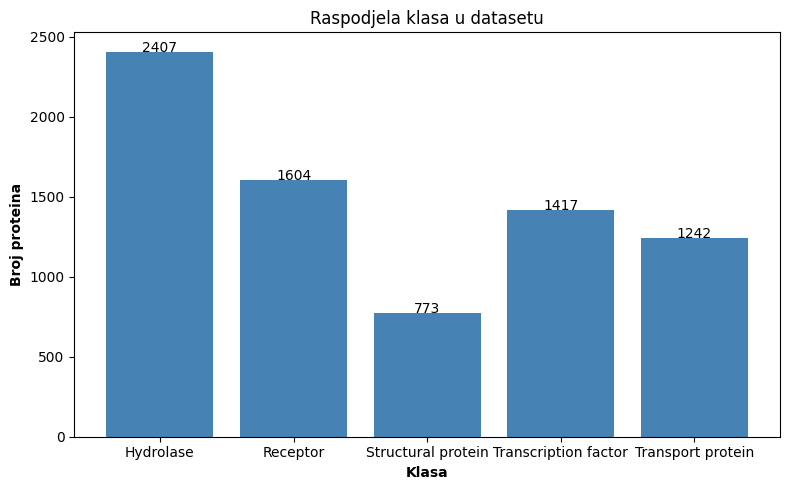

In [12]:
class_counts = pd.Series(y).value_counts().sort_index()
labels = le.inverse_transform(class_counts.index)

plt.figure(figsize=(8, 5))
plt.bar(labels, class_counts.values, color="steelblue")
plt.title("Raspodjela klasa u datasetu")
plt.xlabel("Klasa", fontweight="bold")
plt.ylabel("Broj proteina", fontweight="bold")

for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.tight_layout()
plt.show()

### Podjela na skup za treniranje i testiranje

In [13]:
# Train/Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train skup:  {len(x_train)} proteina (80%)")
print(f"Test skup:  {len(x_test)} proteina (20%)")

Train skup:  5954 proteina (80%)
Test skup:  1489 proteina (20%)


### Count Vectorizer

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
# Definisanje Count Vectorizer parametara
cv_params = dict(analyzer='char', ngram_range=(1, 3), min_df=2)

test_vec = CountVectorizer(**cv_params)
test_vec.fit(x_train)

print(f"Dimenzija vektora: {len(test_vec.get_feature_names_out())}")
print("Prvih 10 k-mera:")
print(test_vec.get_feature_names_out()[:10])

Dimenzija vektora: 8420
Prvih 10 k-mera:
['a' 'aa' 'aaa' 'aac' 'aad' 'aae' 'aaf' 'aag' 'aah' 'aai']


## Definisanje ML modela

- **SVM** (Support Vector Machine) 
- **Random Forest** 
- **Naive Bayes** 

### Support Vector Machine (SVM)

In [30]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [37]:
# Defnisanje SVM Pipeline
svm_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(**cv_params)),
    ('classifier', LinearSVC(C=1.0, class_weight='balanced', random_state=42))
])

svm_pipeline.fit(x_train, y_train)

C:\Users\EC\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(**cv_params)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

rf_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Naive Bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB
from imblearn.under_sampling import RandomUnderSampler

In [21]:
rus = RandomUnderSampler(random_state=42)
x_train_rus, y_train_rus = rus.fit_resample(x_train.reshape(-1, 1), y_train)
x_train_rus = x_train_rus.reshape(-1)

In [48]:
nb_pipeline = Pipeline([
    ('vecortizer', CountVectorizer(**cv_params)),
    ('classifier', MultinomialNB())
])

nb_pipeline.fit(x_train_rus, y_train_rus)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vecortizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Evaluacija

In [23]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

def report(model, x, y, text):
    print(text)
    y_pred = model.predict(x)

    print("---------------------------------------------------------------------------------")
    print("Classification report:")
    print("---------------------------------------------------------------------------------")
    print(classification_report(y, y_pred))
    print("---------------------------------------------------------------------------------")
    print("Confusion matrix:")
    print("---------------------------------------------------------------------------------")
    print(pd.DataFrame(confusion_matrix(y, y_pred), columns=le.classes_, index=le.classes_))
    print("---------------------------------------------------------------------------------")
 

In [42]:
report(svm_pipeline, x_train, y_train, "SVM - Trening skup")

SVM - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1925
           1       0.98      0.91      0.94      1283
           2       0.98      0.91      0.94       618
           3       0.98      0.98      0.98      1134
           4       0.90      0.97      0.93       994

    accuracy                           0.95      5954
   macro avg       0.96      0.95      0.95      5954
weighted avg       0.95      0.95      0.95      5954

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                  1877         3                 

In [43]:
report(svm_pipeline, x_test, y_test, "SVM - Test skup")

SVM - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       482
           1       0.73      0.68      0.71       321
           2       0.66      0.55      0.60       155
           3       0.84      0.84      0.84       283
           4       0.53      0.59      0.56       248

    accuracy                           0.70      1489
   macro avg       0.69      0.68      0.68      1489
weighted avg       0.70      0.70      0.70      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   350        25                  26

In [45]:
report(rf_pipeline, x_train, y_train, "Random Forest - Trening skup")

Random Forest - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1925
           1       0.96      0.93      0.94      1283
           2       0.94      0.99      0.96       618
           3       0.98      0.98      0.98      1134
           4       0.89      0.98      0.93       994

    accuracy                           0.96      5954
   macro avg       0.95      0.96      0.96      5954
weighted avg       0.96      0.96      0.96      5954

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                  1815        21       

In [46]:
report(rf_pipeline, x_test, y_test, "Random Forest - Test skup")

Random Forest - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.55      0.86      0.67       482
           1       0.72      0.52      0.61       321
           2       0.73      0.49      0.59       155
           3       0.88      0.76      0.82       283
           4       0.63      0.38      0.47       248

    accuracy                           0.65      1489
   macro avg       0.70      0.60      0.63      1489
weighted avg       0.68      0.65      0.64      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   415        21          

In [ ]:
report(nb_pipeline, x_train_rus, y_train_rus, "Naive Bayes - Trening skup")

Naibe Bayes - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.51      0.78      0.61       618
           1       0.82      0.74      0.77       618
           2       0.61      0.51      0.56       618
           3       0.96      0.71      0.81       618
           4       0.77      0.77      0.77       618

    accuracy                           0.70      3090
   macro avg       0.73      0.70      0.70      3090
weighted avg       0.73      0.70      0.70      3090

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   481        41         

In [50]:
report(nb_pipeline, x_test, y_test, "Naive Bayes - Test skup")

Naive Bayes - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.71      0.68       482
           1       0.75      0.65      0.70       321
           2       0.36      0.52      0.43       155
           3       0.97      0.65      0.78       283
           4       0.60      0.69      0.64       248

    accuracy                           0.66      1489
   macro avg       0.67      0.64      0.64      1489
weighted avg       0.70      0.66      0.67      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   341        34            